In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [9]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\housing.csv")

In [10]:
df.head(3)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,NaN,544759.48,2.75,2.37,1738.12,7061.69,1.04,0.0,0.0,...,7.37,1276.54,633.87,2073.77,0.00,98115,46.81,-105.85,1839.00,7988.89
1,2,NaN,256014.26,2.09,1.00,955.83,5446.83,0.98,0.0,0.0,...,6.72,967.36,0.00,1865.12,0.00,98118,45.48,-122.08,1098.57,7088.26
2,3,NaN,453929.37,2.99,1.87,1829.94,5434.09,1.08,0.0,0.0,...,7.63,1911.94,0.00,1978.20,2124.24,98028,48.56,-125.89,1971.28,4687.11


In [11]:
df.isnull().sum()

id                  0
date             9596
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
grade               0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   date           404 non-null    float64
 2   price          10000 non-null  float64
 3   bedrooms       10000 non-null  float64
 4   bathrooms      10000 non-null  float64
 5   sqft_living    10000 non-null  float64
 6   sqft_lot       10000 non-null  float64
 7   floors         10000 non-null  float64
 8   waterfront     10000 non-null  float64
 9   view           10000 non-null  float64
 10  condition      10000 non-null  float64
 11  grade          10000 non-null  float64
 12  sqft_above     10000 non-null  float64
 13  sqft_basement  10000 non-null  float64
 14  yr_built       10000 non-null  float64
 15  yr_renovated   10000 non-null  float64
 16  zipcode        10000 non-null  int64  
 17  lat            10000 non-null  float64
 18  long   

In [14]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,10000.00000,4.040000e+02,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.016373e+07,5.192427e+05,3.130086,2.302209,2009.780439,6936.568403,1.482432,0.142311,0.471873,...,7.862601,1640.142815,374.874741,1985.014594,36.169198,98080.926000,47.658463,-122.361213,1998.237576,6851.716898
std,2886.89568,9.519293e+05,2.003515e+05,0.793427,0.829640,728.130426,2660.992835,0.506244,0.350337,1.042644,...,1.578778,484.983302,367.758893,102.604739,267.524716,44.124225,2.370694,6.079147,670.337023,2426.208559
min,1.00000,1.714041e+07,2.122776e+05,1.670000,0.830000,817.730000,3190.180000,0.820000,0.000000,0.000000,...,5.040000,760.810000,0.000000,1519.200000,0.000000,98004.000000,39.020000,-151.090000,853.600000,3398.130000
25%,2500.75000,1.948803e+07,3.735376e+05,2.800000,1.890000,1601.297500,4927.790000,1.000000,0.000000,0.000000,...,6.750000,1314.690000,0.000000,1917.125000,0.000000,98052.000000,46.080000,-126.450000,1649.355000,5079.562500
50%,5000.50000,2.015031e+07,4.751307e+05,3.030000,2.160000,1909.300000,6286.150000,1.090000,0.000000,0.000000,...,7.500000,1621.645000,483.670000,1985.250000,0.000000,98103.000000,47.670000,-122.330000,1928.830000,6200.800000
75%,7500.25000,2.080046e+07,6.144143e+05,3.790000,2.850000,2470.402500,7953.755000,2.000000,0.000000,0.000000,...,8.770000,1858.305000,710.797500,2053.305000,0.000000,98115.000000,49.260000,-118.207500,2373.435000,7780.315000
max,10000.00000,2.257030e+07,1.351388e+06,5.690000,5.070000,4701.310000,19007.690000,2.340000,1.160000,4.600000,...,13.670000,4236.640000,1268.940000,2453.590000,2279.430000,98155.000000,56.380000,-100.230000,4519.010000,17130.950000


In [15]:
df['date'].unique()

array([      nan, 19330524., 20800130., 20610610., 20840918., 19240205.,
       20420708., 19250810., 20521117., 19331019., 19000423., 19591021.,
       21390516., 21040605., 20970630., 19280527., 17820302., 20350401.,
       21490909., 19980907., 19851118., 20780128., 22570302., 20560629.,
       20800311., 20870206., 20431213., 20541111., 21970925., 20180615.,
       22030620., 19181127., 19760407., 21780905., 20220429., 20740607.,
       20000411., 21560928., 19170516., 20060816., 19140618., 20971010.,
       19501004., 21760324., 19351006., 19690816., 20470131., 19040716.,
       20480122., 20100117., 20990607., 19831110., 20971107., 18550806.,
       20601014., 20720714., 19501006., 20351123., 18970207., 19590324.,
       19451023., 19970907., 20040319., 20030427., 19970224., 21370625.,
       20430621., 21021207., 19130222., 20010816., 20130901., 20660421.,
       21410901., 20821224., 18861122., 19951222., 19560406., 19430622.,
       18801029., 19060513., 20780809., 20320526., 

In [16]:
df.shape

(10000, 21)

In [17]:
df['date'] = pd.date_range(end=pd.Timestamp.today(), periods=10000).strftime('%Y-%m-%d')

In [18]:
df['date'].shape

(10000,)

In [19]:
df.head(3)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,1998-10-08,544759.48,2.75,2.37,1738.12,7061.69,1.04,0.0,0.0,...,7.37,1276.54,633.87,2073.77,0.00,98115,46.81,-105.85,1839.00,7988.89
1,2,1998-10-09,256014.26,2.09,1.00,955.83,5446.83,0.98,0.0,0.0,...,6.72,967.36,0.00,1865.12,0.00,98118,45.48,-122.08,1098.57,7088.26
2,3,1998-10-10,453929.37,2.99,1.87,1829.94,5434.09,1.08,0.0,0.0,...,7.63,1911.94,0.00,1978.20,2124.24,98028,48.56,-125.89,1971.28,4687.11


In [20]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
9995,9996,2026-02-18,375443.30,3.03,1.90,1622.74,4312.60,0.96,0.00,0.00,...,7.10,1626.32,0.00,1866.73,0.0,98108,47.64,-127.15,1689.65,4515.79
9996,9997,2026-02-19,474900.06,3.03,2.36,2258.73,6499.79,2.11,0.00,0.00,...,7.38,1507.92,589.41,1954.97,0.0,98107,47.18,-137.84,2070.33,6277.62
9997,9998,2026-02-20,387024.60,3.28,2.15,1682.88,4534.32,0.92,0.00,0.00,...,6.88,1746.93,0.00,2055.41,0.0,98074,46.45,-115.74,1591.57,4367.45
9998,9999,2026-02-21,728852.02,4.08,3.34,2926.08,9694.75,2.07,1.09,1.95,...,10.04,1998.14,747.69,2134.96,0.0,98040,48.98,-124.90,2790.77,9006.22
9999,10000,2026-02-22,301743.48,1.92,0.98,1016.29,4024.08,0.94,0.00,0.00,...,5.37,890.79,0.00,1937.53,0.0,98144,46.97,-119.56,1150.03,4144.48


In [21]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['months'] = df['date'].dt.month

df.drop('date', axis=1, inplace=True)

In [22]:
df.drop('id', axis = 1, inplace=True)

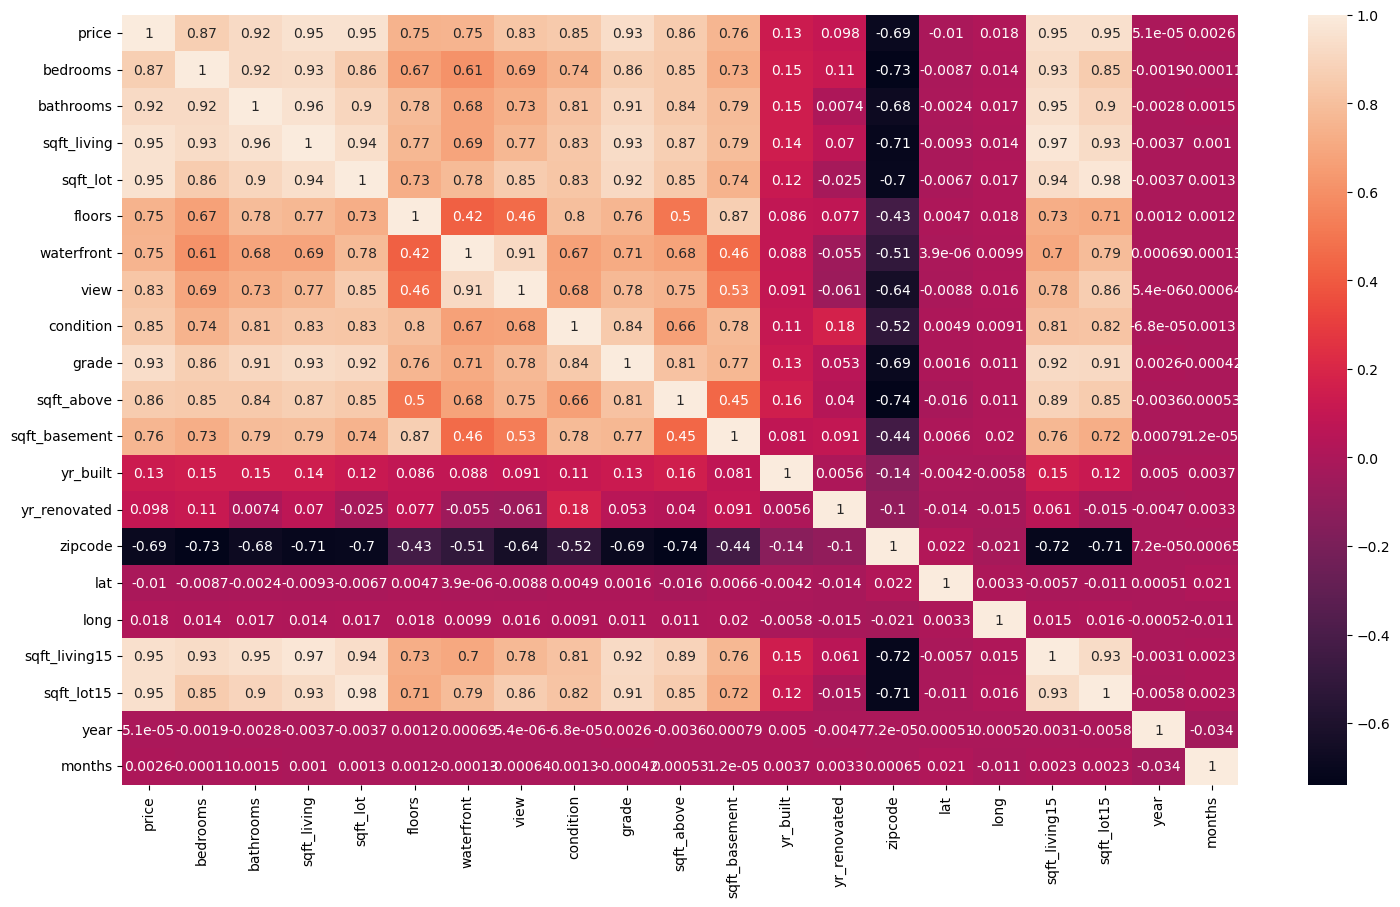

In [23]:
plt.figure(figsize=(18,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

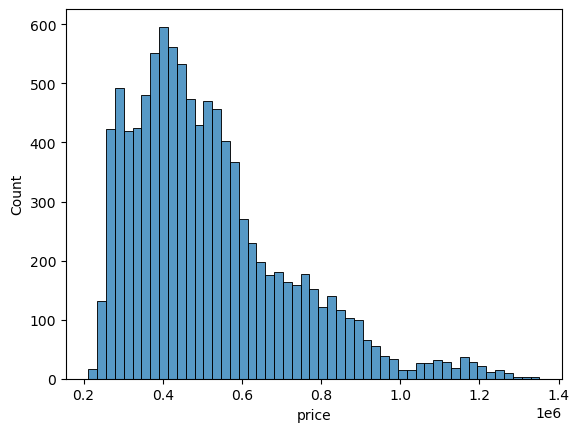

In [24]:
sns.histplot(df['price'])
plt.show()

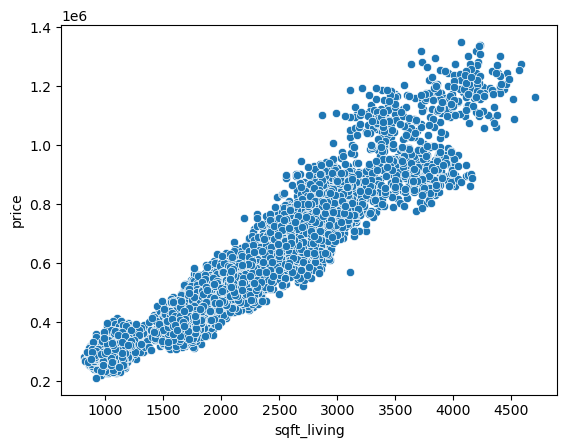

In [25]:
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.show()

In [26]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'year', 'months'],
      dtype='object')

In [27]:
X = df.drop(['price', 'sqft_lot','waterfront', 'view', 'condition', 'grade', 'sqft_above','sqft_basement', 'yr_renovated', 'zipcode', 'lat', 'long','sqft_living15', 'sqft_lot15', 'year', 'months'], axis=1)
y = df['price']

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42 )

In [29]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
model1 = RandomForestRegressor()
model1.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
model_pred = model.predict(X_test)
model1_pred = model1.predict(X_test)

accuracy = r2_score(y_test, model_pred)
accuracy1 = r2_score(y_test, model1_pred)

In [32]:
print('Linear Regression R2:', accuracy)
print('Random Forest Regression R2:', accuracy1)

Linear Regression R2: 0.9137254332603582
Random Forest Regression R2: 0.945679295974946


In [33]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(model1, "models/house_model.pkl")

print("Model saved successfully!")

Model saved successfully!
